# Introduction

Titanic is a ship sunk in a major shipwreck. This accident happened in 1912. As a result of this accident, 1502 people died.

<font color = pink >
 Content:
    
 1. [Load and Check Data](#1)</br>
 2. [Variable Description](#2)
* [Univariate Variable Analysis](#3)
* * [Categorical Variable Analysis](#4)
* * [Numerical Variable Analysis](#5)
 1. [Basic Data Analysis](#6)
 1. [Outlier Detection](#7)
 1. [Missing Value](#8)
    * [Find Missing Value](#9)    
    * [Fill Missing Value](#10) 
 1. [Visualization](#11)
    * [Correlation Between Sibsp -- Parch -- Age -- Fare -- Survived](#12)
    * [SibSp -- Survived](#13)
    * [Parch -- Survived](#14)
    * [Pclass -- Survived](#15)
    * [Age -- Survived](#16)
    * [Pclass -- Survived -- Age](#17)
    * [Embarked -- Sex -- Pclass -- Survived](#18)
    * [Embarked -- Sex -- Fare -- Survived](#19)
    * [Fill Missing: Age Feature](#20)
 1. [Future Engineering](#21)
    * [Name -- Title](#22)
    * [Famiy Size](#23)
    * [Embarked](#24)
    * [Ticket](#25)
    * [Pclass](#26)
    * [Sex](#27)
    * [Drop Passenger ID and Cabin](#28)
 1. [Modelling](#29)
    * [Train - Test Split](#30)
    * [Simple Logistic Regression](#31)
    * [Hyperparameter Tuning -- Grid Search -- Cross Validation](#32)
    * [Ensemble Modelling](#33)
    * [Prediction and  Submission](#34)


    
    
     
    

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


<a id = "1"></a>
## Load and Check Data

In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_passengerId = test_data["PassengerId"]

In [3]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<a id = "2"></a>
# Variable Description


1. PassengerId : unique id number for each passenger
1. Survived : passenger survived (1) or died(0)
1. Pclass : passenger class
1. Name : name 
1. Sex : gender
1. Age : age
1. SibSp : number of siblings / spouses
1. Parch : number of parents / children
1. Ticket : ticket number
1. Fare : amount of ticket money
1. Cabin : cabin category
1. Embarked : ports where passengers board the ship (C = Cherbourg, Q = Queenstown, S = Southhampton9

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* float64(2) : Fare and Age
* int64(5) : Pclass, sibsp, parch, passengerId and survived
* object(5) : Cabin, embarked, ticket, name, gender

<a id = "3"></a>
# Univariate Variable Analysis
* Categorical Variable : Survived, Sex, Pclass, Embarked, Cabin, Name, Ticket, Sibsp, Parch 
* Numeric Variable : Fare, age and passengerId

<a id = "4"></a>
## Categorical Variable 




In [8]:
def bar_plot(variable):
    """
        input: variable for example: "Sex"
        output: bar plot & value count
    """
    
    # get feature
    var = train_data[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()
    #visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

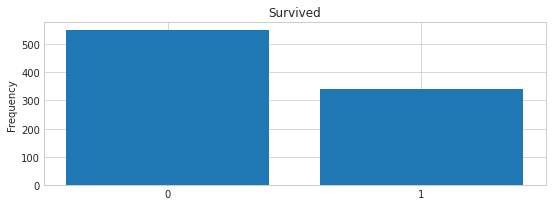

Survived: 
 0    549
1    342
Name: Survived, dtype: int64


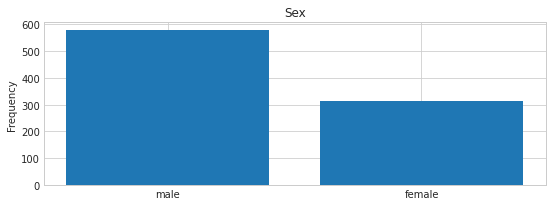

Sex: 
 male      577
female    314
Name: Sex, dtype: int64


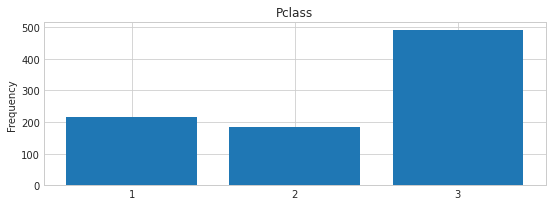

Pclass: 
 3    491
1    216
2    184
Name: Pclass, dtype: int64


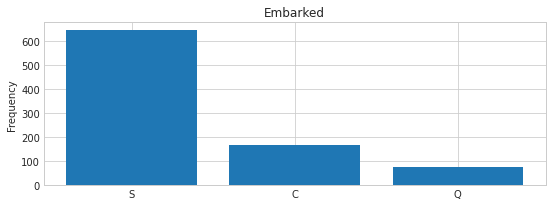

Embarked: 
 S    644
C    168
Q     77
Name: Embarked, dtype: int64


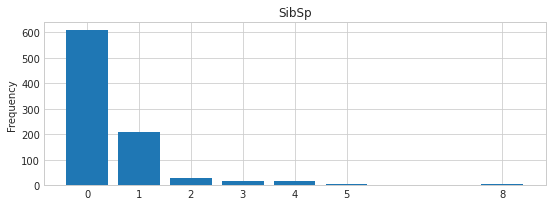

SibSp: 
 0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64


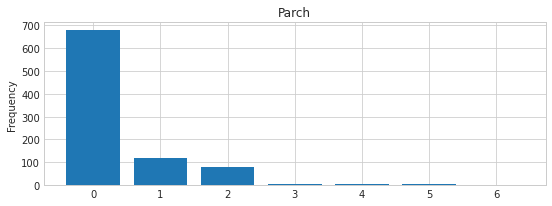

Parch: 
 0    678
1    118
2     80
3      5
5      5
4      4
6      1
Name: Parch, dtype: int64


In [9]:
category1 = ["Survived", "Sex", "Pclass", "Embarked","SibSp","Parch"]
for c in category1:
    bar_plot(c)

In [10]:
category2 = ["Cabin","Name","Ticket"]
for c in category2:
    print("{} \n".format(train_data[c].value_counts)) # çok karmasik bir yapısı var

<bound method IndexOpsMixin.value_counts of 0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object> 

<bound method IndexOpsMixin.value_counts of 0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object> 

<bound method IndexOpsMixin.value_counts of 0             A/5 21171


<a id = "5"></a>
## Numerical Variable 

In [11]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(train_data[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

In [12]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

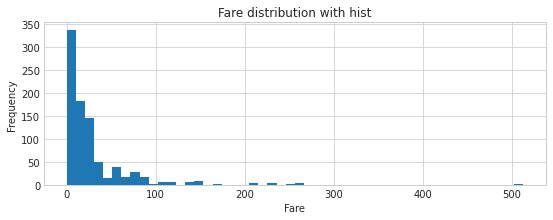

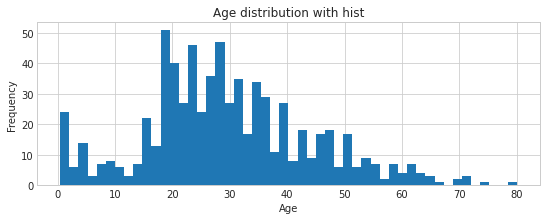

In [13]:
numericVar = ["Fare","Age"]
for n in numericVar:
    plot_hist(n)

<a id = "6"></a></br>
## Basic Data Analysis


* Pclass - Survived Does it have to do with the survival of the class of passengers?
* Sex - Survived Does the gender of passengers have anything to do with survival?
* SibSp - Does the number of people in the families of Survived Passengers have anything to do with their survival?
* Parch - Does the number of people in the families of Survived Passengers have anything to do with their survival?

In [14]:
train_data[["Pclass","Survived"]]

,Pclass,Survived
0,3,0
1,1,1
2,3,1
3,1,1
4,3,0
...,...,...
886,2,0
887,1,1
888,3,0
889,1,1


Firstly we looking for **Pclass vs Survived** relationship. When we looking up this, we use groupby method because we want to know which Pclass have how much survived.

In [15]:
#Pclass vs Survived
train_data[["Pclass","Survived"]].groupby(["Pclass"], as_index =False).mean().sort_values(by = "Survived", ascending =  False)


,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [16]:
# Sex vs Survived
train_data[["Sex","Survived"]].groupby(["Sex"], as_index = False).mean().sort_values(by = "Survived", ascending =  False)


,Sex,Survived
0,female,0.742038
1,male,0.188908


In [17]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [18]:
#Sibsp vs Survived
train_data[["SibSp","Survived"]].groupby(["SibSp"], as_index = False).mean().sort_values(by = "Survived", ascending =  False)


,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [19]:
### Parch vs Survived
train_data[["Parch","Survived"]].groupby(["Parch"], as_index = False).mean().sort_values(by = "Survived", ascending = False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


Parch-SibSp together Survived 

In [20]:
train_data[["Parch","SibSp","Survived"]].groupby(["Parch","SibSp"],as_index = False).mean().sort_values(by = "Survived",ascending = False)

,Parch,SibSp,Survived
16,3,0,1.000000
3,0,3,1.000000
18,3,2,1.000000
6,1,2,0.857143
9,2,0,0.724138
4,1,0,0.657895
10,2,1,0.631579
5,1,1,0.596491
1,0,1,0.520325
11,2,2,0.500000


In [21]:
#Age vs Fare ilişkisine bakalım
train_data[["Age","Fare"]].groupby(["Fare"],as_index = False).mean().sort_values(by = "Age",ascending = False)

,Fare,Age
166,34.6542,71.0
200,61.9792,65.0
163,33.5000,61.0
160,32.3208,61.0
3,6.2375,61.0
...,...,...
167,35.0000,NaN
178,42.4000,NaN
183,50.0000,NaN
205,69.5500,NaN


In [22]:
# Age vs Survived
train_data[["Age","Survived"]].groupby(["Survived"],as_index = False).mean().sort_values("Survived")

,Survived,Age
0,0,30.626179
1,1,28.343690


* parch ve sibsp arasında bir benzerlik yakalayamadık corelation yok gibi görünüyor.  
* Bu bizim farklı fikirler edinmemize yardımcı olabilir.
* parch ve sibsp yi birleştirerek yeni bir feature ortaya çıkarabiliriz.


<a id = "7"></a></br>
# Outlier Detection

* Let's think of data that is too big or too small than other data.

In [23]:
def detect_outliers(df, features):
    outlier_indices = []
    
    for c in features:
        # 1st quartile
        Q1 = np.percentile(df[c],25)
        
        #3rd quartile
        Q3 = np.percentile(df[c],75)
        
        #IQR
        IQR = Q3 - Q1
        
        #Outlier step
        outlier_step = IQR * 1.5
        
        # detect outlier and their indices
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        # store indices
        outlier_indices.extend(outlier_list_col)
    
    outlier_indices = Counter(outlier_indices)
    # counter metodu ile elemanların kaçar tane outlier içerdiğini saymış oluruz.
    # bu sayede tek bir featureda outlier bulursak o veriyi çıkarmayabilriz.
    
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)
    
    return multiple_outliers

In [24]:
train_data.loc[detect_outliers(train_data,["Age","SibSp","Parch","Fare"])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [25]:
#drop outliers
train_data = train_data.drop(detect_outliers(train_data,["Age","SibSp","Parch","Fare"]), axis = 0).reset_index(drop = True)

<a id = "8"></a></br>
# Missing Value
  * Find Missing Value
  * Fill Missing Value

In [26]:
#We will combine our train and test data before looking at missing values.
#If we just fill in the missing values in the train_data and do not look at the tests,
#our machine learning model will fail when it sees the gaps in the test data. It will not be able to recognize them.


train_data_len = len(train_data)
train_data = pd.concat([train_data,test_data],axis = 0).reset_index(drop = True) 

In [27]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<a id = "9"></a></br>
## Find Missing Value

In [28]:
train_data.columns[train_data.isnull().any()] # We determined which columns have missing value.


Index(['Survived', 'Age', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [29]:
train_data.isnull().sum() # How many null values are in which feature we found them
#Survived have 418 null value because It is test data's survived column

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             256
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1007
Embarked          2
dtype: int64

<a id = "10"></a></br>
## Fill Missing Value

* Embarked has 2 missing values
* Fare has 1 missing value

In [30]:
#We can delete these missing values instead of filling them. But losing data is not something we want.
train_data[train_data["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
60,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
821,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


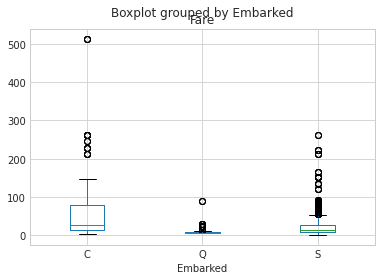

In [31]:
# We can fill the Embarked according to people with the same fare paid. 
#So we make a guess as if they might have gotten from the same place.
train_data.boxplot(column = "Fare", by = "Embarked")
plt.show()

Boxplota baktığımızda, fare = 80 olanlar için en uygun liman C limanıdır. C olarak doldurabiliriz. 

In [32]:
train_data["Embarked"]  = train_data["Embarked"].fillna("C")


In [33]:
train_data[train_data["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [34]:
train_data[train_data["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1033,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [35]:
#Pclass = 3 olanları alıp bakalım

train_data["Fare"] = train_data["Fare"].fillna(np.mean(train_data[train_data["Pclass"]==3]["Fare"]))

<a id = "11"></a><br>
# Visualization

<a id = "12"></a><br>
### Correlation Between Sibsp -- Parch -- Age -- Fare -- Survived

<AxesSubplot:>

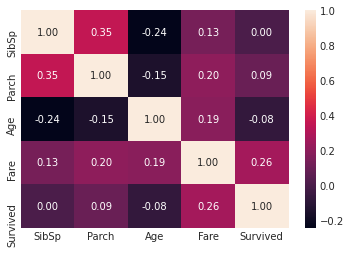

In [36]:
list1 = ["SibSp","Parch","Age","Fare","Survived"]
sns.heatmap(train_data[list1].corr(),annot = True,fmt =".2f")

Fare feature seems to have correlation with survived feature (0.26)

<a id = "13"></a><br>
### SibSp -- Survived
    

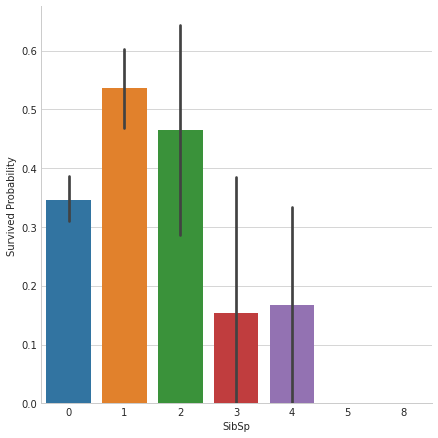

In [37]:
g = sns.factorplot(x ="SibSp", y = "Survived", data = train_data, kind = "bar",size = 6)
g.set_ylabels("Survived Probability")
plt.show()

* Having a lot of SibSp have less chance to survive.
* if SibSp == 0 or 1 or 2, passenger has more chance to survive
* we can consider a new feature describing these categories.

<a id = "14"></a><br>
### Parch -- Survived

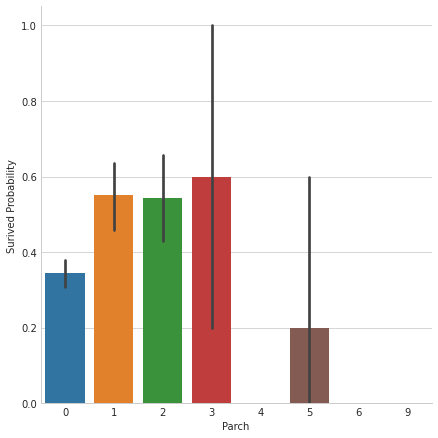

In [38]:
g = sns.factorplot(x = "Parch",y = "Survived",data = train_data,kind = "bar",size = 6)
g.set_ylabels("Surived Probability")
plt.show()

* SibSp and Parch can be used for new feature exraction with th = 3
* small families have more chance to survive.
* there is a std in survival of passenger with Parch = 3

<a id = "15"></a><br>
### Pclass -- Survived

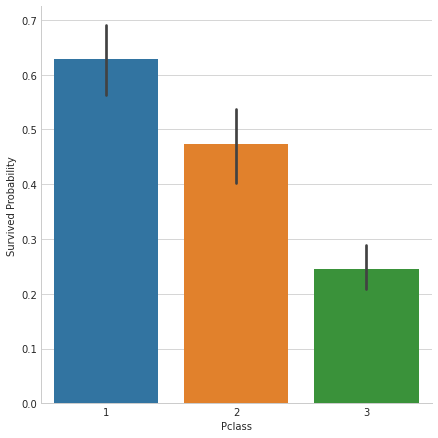

In [39]:
g = sns.factorplot(x = "Pclass",y = "Survived",data = train_data,kind="bar",size = 6)
g.set_ylabels("Survived Probability")
plt.show()

  <a id = "16"></a><br>

  ### Age -- Survived

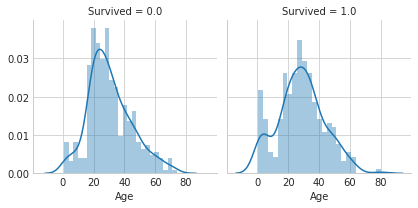

In [40]:
g = sns.FacetGrid(train_data, col = "Survived")
g.map(sns.distplot, "Age",bins = 25)
plt.show()

* age<= 10 has a high survival rate
* large number of 20 years old is not survive,
* most passengers are in 15-35
* use age feature in training
* use age distribution for missing value of age

<a id = "17"></a><br>

### Pclass -- Survived -- Age

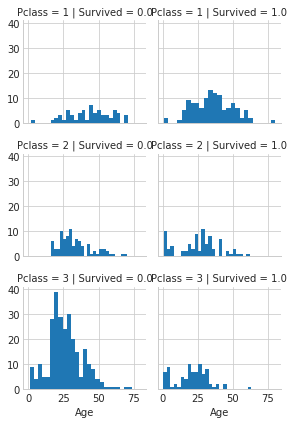

In [41]:
g = sns.FacetGrid(train_data, col = "Survived", row = "Pclass",size = 2)
g.map(plt.hist, "Age",bins = 25)
g.add_legend()
plt.show()

* Pclass is important feature for model training

<a id = "18"></a><br>

### Embarked -- Sex -- Pclass -- Survived

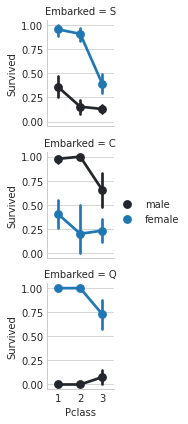

In [42]:
g = sns.FacetGrid(train_data,row = "Embarked",size = 2)
g.map(sns.pointplot, "Pclass","Survived", "Sex")
g.add_legend()

*  Female passengers have much better survival rate than male.
* males have better survival rate in pclass 3 in C.
* embarked and sex will be used in training.

<a id = "19"></a><br>

### Embarked -- Sex -- Fare -- Survived

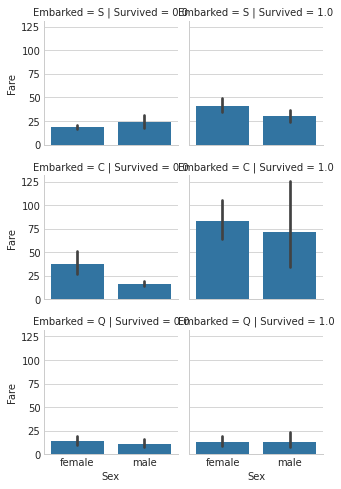

In [43]:
g = sns.FacetGrid(train_data, row= "Embarked",col = "Survived", size = 2.3)
g.map(sns.barplot,"Sex","Fare")
g.add_legend()
plt.show()

* passengers who pay higher fare have better survival. Fare can be used as categorical for training.

<a id = "20"></a><br>

### Fill Missing: Age Feature

In [44]:
train_data[train_data["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1.0,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0.0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
27,29,1.0,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
1289,1300,NaN,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
1291,1302,NaN,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
1294,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1297,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


* 1) Erkeklerin ortalama yaşına göre, kadınların yaşlarını ortalama kadın yaşına göre doldurabiliriz.
* 2) Pclasslara bakıp o classdaki erkeklerin yaş ortalmalarına göre doldurabiliriz.
* 3) Parch ve SibSp ye göre yapabiliriz.(birinin çocuğuysa küçük olabilir. Birinin annesi veya babasıysa yaşı büyüktür)


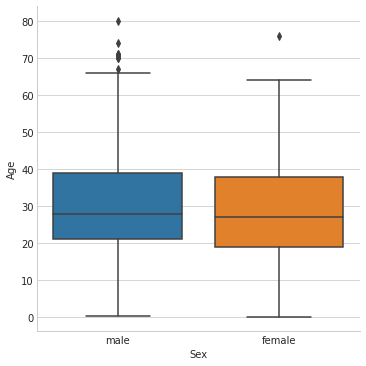

In [45]:
sns.factorplot(x = "Sex",y = "Age", data = train_data,kind = "box")
plt.show()

* Sex is not informative for age prediction because female and male age median almost same.

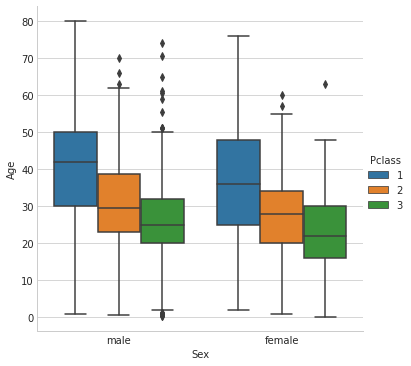

In [46]:
sns.factorplot(x = "Sex", y = "Age", hue = "Pclass",data = train_data, kind ="box")
plt.show()

* 1st class passengers are older than 2nd, and 2nd class is older than 3rd class.

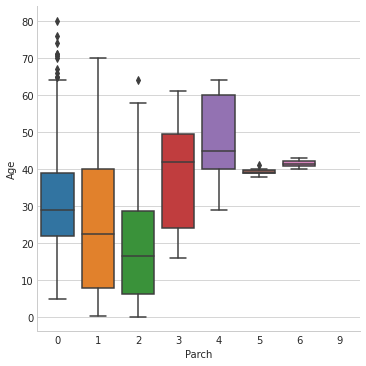

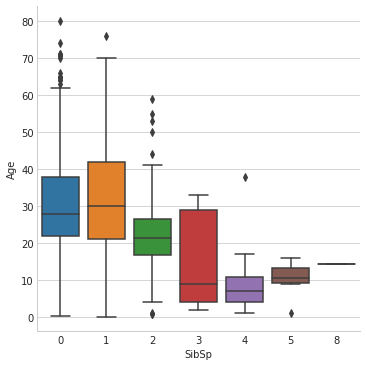

In [47]:
sns.factorplot(x = "Parch", y = "Age",data = train_data, kind ="box")
sns.factorplot(x = "SibSp", y = "Age",data = train_data, kind ="box")
plt.show()

In [48]:
train_data["Sex"] = [1 if i == "male" else 0 for i in train_data["Sex"]]

<AxesSubplot:>

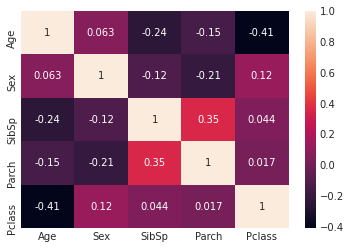

In [49]:
sns.heatmap(train_data[["Age","Sex","SibSp","Parch","Pclass"]].corr(), annot = True)

* Age is not corelated with sex but it is corelated with Parch, SibSp and Pclass.

In [50]:
index_nan_age = list(train_data["Age"][train_data["Age"].isnull()].index)
index_nan_age
for i in index_nan_age:
    age_pred = train_data["Age"][((train_data["SibSp"] == train_data.iloc[i]["SibSp"]) & (train_data["Parch"] == train_data.iloc[i]["Parch"]) & (train_data["Pclass"] == train_data.iloc[i]["Pclass"]))].median()
    age_med = train_data["Age"].median()
    if not np.isnan(age_pred):
        train_data["Age"].iloc[i] = age_pred
    else: 
        train_data["Age"].iloc[i] = age_med

In [51]:
train_data[train_data["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [52]:
age_med

26.0

In [53]:
age_pred

16.0

<a id = "21"></a><br>
# Future Engineering

<a id = "22"></a><br>
##  Name -- Title

In [54]:
train_data["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [55]:
s =" McCarthy, Mr. Timothy J"
s.split(".")[0].split(",")[-1].strip()

'Mr'

In [56]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [57]:
name = train_data["Name"]

In [58]:
train_data["Title"] = [i.split(".")[0].split(",")[-1].strip() for i in name]

In [59]:
train_data["Title"].head(10)

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
5        Mr
6        Mr
7    Master
8       Mrs
9       Mrs
Name: Title, dtype: object

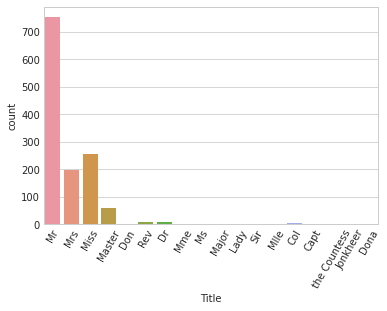

In [60]:
sns.countplot(x="Title", data = train_data)
plt.xticks(rotation = 60)
plt.show()

In [61]:
# convert to categorical 
train_data["Title"] = train_data["Title"].replace(["Lady","the Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],"other")
train_data["Title"] = [0 if i == "Master" else 1 if i == "Miss"or i == "Ms" or i == "Mlle" or i == "Mrs" else 2 if i == "Mr" else 3 for i in train_data["Title"]]
train_data["Title"].head(10)

0    2
1    1
2    1
3    1
4    2
5    2
6    2
7    0
8    1
9    1
Name: Title, dtype: int64

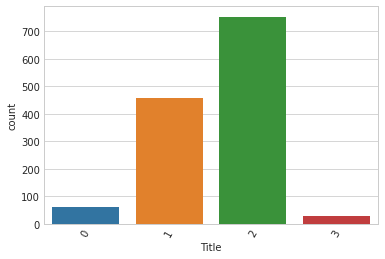

In [62]:
sns.countplot(x="Title", data = train_data)
plt.xticks(rotation = 60)
plt.show()

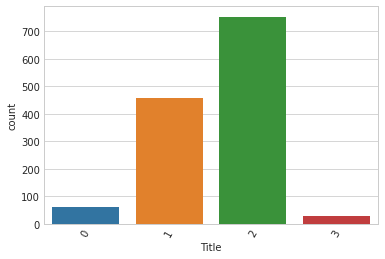

In [63]:
sns.countplot(x="Title", data = train_data)
plt.xticks(rotation = 60)
plt.show()

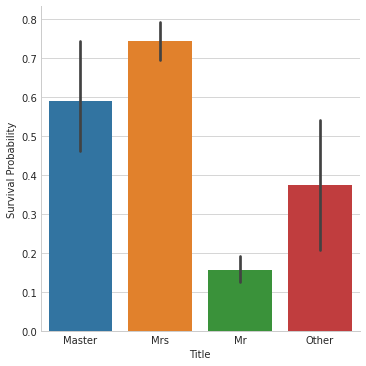

In [64]:
g = sns.factorplot(x = "Title", y = "Survived", data = train_data, kind = "bar")
g.set_xticklabels(["Master","Mrs","Mr","Other"])
g.set_ylabels("Survival Probability")
plt.show()

In [65]:
train_data.drop(labels = ["Name"], axis = 1, inplace = True)


In [66]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,2


In [67]:
train_data = pd.get_dummies(train_data, columns = ["Title"])
train_data.head() # bu sayede kategori sayısı 4'den 2'ye düştü. feature sayısı arttı.

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0


<a id = "23"></a><br>
## Family Size

In [68]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0


In [69]:
train_data["Fsize"] = train_data["SibSp"] + train_data["Parch"] +1 

In [70]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3,Fsize
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,2
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0,2
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0,2
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1


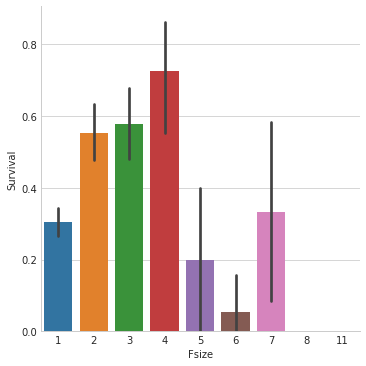

In [71]:
g = sns.factorplot(x = "Fsize", y = "Survived", data = train_data, kind = "bar")
g.set_ylabels("Survival")
plt.show()

In [72]:
#ilk seçenek fsize ı 2 3 ve 4 olanları bir kategori, 1 ve 7 olanları bir kategori, 5 ve 6 olanları bir kategori yapmak olabilir.
# ya da direkt bir threshold belirleyebiliriz. 
train_data["family_size"] = [1 if i < 5 else 0 for i in train_data["Fsize"]]


In [73]:
train_data.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3,Fsize,family_size
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,2,1
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0,2,1
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,1,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0,2,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1,1
5,6,0.0,3,1,25.0,0,0,330877,8.4583,NaN,Q,0,0,1,0,1,1
6,7,0.0,1,1,54.0,0,0,17463,51.8625,E46,S,0,0,1,0,1,1
7,8,0.0,3,1,2.0,3,1,349909,21.0750,NaN,S,1,0,0,0,5,0
8,9,1.0,3,0,27.0,0,2,347742,11.1333,NaN,S,0,1,0,0,3,1
9,10,1.0,2,0,14.0,1,0,237736,30.0708,NaN,C,0,1,0,0,2,1


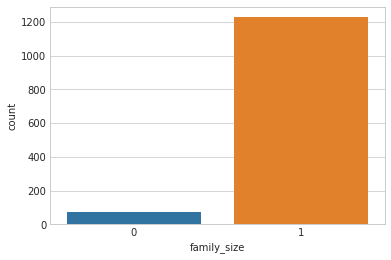

In [74]:
sns.countplot(x = "family_size", data = train_data)
plt.show()

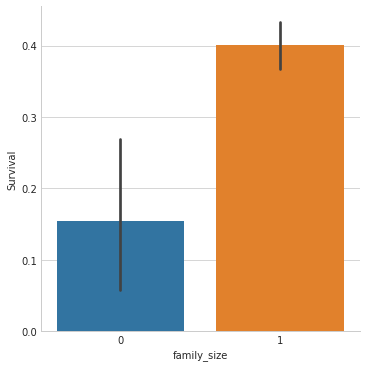

In [75]:
g = sns.factorplot(x = "family_size", y = "Survived", data = train_data, kind = "bar")
g.set_ylabels("Survival")
plt.show()

Small families have more chance to survive than large families.

In [76]:
train_data = pd.get_dummies(train_data, columns = ["family_size"])
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_0,Title_1,Title_2,Title_3,Fsize,family_size_0,family_size_1
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,2,0,1
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0,2,0,1
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,1,0,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,S,0,1,0,0,2,0,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,1,0,1


<a id = "24"></a><br>
## Embarked

In [77]:
train_data["Embarked"].head()

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object

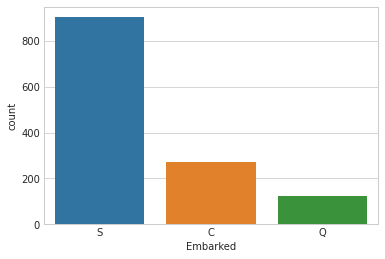

In [78]:
sns.countplot(x = "Embarked", data = train_data)
plt.show()

In [79]:
train_data = pd.get_dummies(train_data, columns = ["Embarked"])
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title_0,Title_1,Title_2,Title_3,Fsize,family_size_0,family_size_1,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,3,1,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1,0,2,0,1,0,0,1
1,2,1.0,1,0,38.0,1,0,PC 17599,71.2833,C85,0,1,0,0,2,0,1,1,0,0
2,3,1.0,3,0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,0,0,1,0,1,0,0,1
3,4,1.0,1,0,35.0,1,0,113803,53.1000,C123,0,1,0,0,2,0,1,0,0,1
4,5,0.0,3,1,35.0,0,0,373450,8.0500,NaN,0,0,1,0,1,0,1,0,0,1


<a id = "24"></a><br>
## Ticket

In [80]:
train_data["Ticket"].head(10)

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
5              330877
6               17463
7              349909
8              347742
9              237736
Name: Ticket, dtype: object

In [81]:
a = "STON/O2. 3101282"
a.replace(".","").replace("/","").strip().split(" ")[0]


'STONO2'

In [82]:
tickets = []
for i in list(train_data.Ticket):
    if not i.isdigit():
        tickets.append(i.replace(".","").replace("/","").strip().split(" ")[0])
    else:
        tickets.append("x")
train_data["Ticket"] = tickets

    

In [83]:
train_data["Ticket"].head(10)

0        A5
1        PC
2    STONO2
3         x
4         x
5         x
6         x
7         x
8         x
9         x
Name: Ticket, dtype: object

In [84]:
train_data = pd.get_dummies(train_data, columns = ["Ticket"], prefix = "T")
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title_0,...,T_SOTONO2,T_SOTONOQ,T_SP,T_STONO,T_STONO2,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x
0,1,0.0,3,1,22.0,1,0,7.2500,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1.0,1,0,38.0,1,0,71.2833,C85,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1.0,3,0,26.0,0,0,7.9250,NaN,0,...,0,0,0,0,1,0,0,0,0,0
3,4,1.0,1,0,35.0,1,0,53.1000,C123,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0.0,3,1,35.0,0,0,8.0500,NaN,0,...,0,0,0,0,0,0,0,0,0,1


<a id = "26"></a><br>
## Pclass

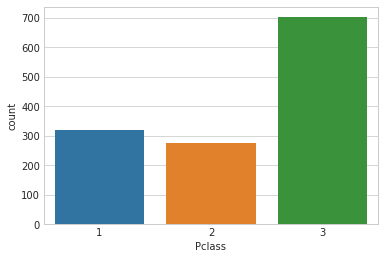

In [85]:
sns.countplot(x = "Pclass", data = train_data)
plt.show()

In [86]:
train_data["Pclass"] = train_data["Pclass"].astype("category")
train_data = pd.get_dummies(train_data, columns= ["Pclass"])
train_data.head(10)

,PassengerId,Survived,Sex,Age,SibSp,Parch,Fare,Cabin,Title_0,Title_1,...,T_STONO,T_STONO2,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3
0,1,0.0,1,22.0,1,0,7.2500,NaN,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1.0,0,38.0,1,0,71.2833,C85,0,1,...,0,0,0,0,0,0,0,1,0,0
2,3,1.0,0,26.0,0,0,7.9250,NaN,0,1,...,0,1,0,0,0,0,0,0,0,1
3,4,1.0,0,35.0,1,0,53.1000,C123,0,1,...,0,0,0,0,0,0,1,1,0,0
4,5,0.0,1,35.0,0,0,8.0500,NaN,0,0,...,0,0,0,0,0,0,1,0,0,1
5,6,0.0,1,25.0,0,0,8.4583,NaN,0,0,...,0,0,0,0,0,0,1,0,0,1
6,7,0.0,1,54.0,0,0,51.8625,E46,0,0,...,0,0,0,0,0,0,1,1,0,0
7,8,0.0,1,2.0,3,1,21.0750,NaN,1,0,...,0,0,0,0,0,0,1,0,0,1
8,9,1.0,0,27.0,0,2,11.1333,NaN,0,1,...,0,0,0,0,0,0,1,0,0,1
9,10,1.0,0,14.0,1,0,30.0708,NaN,0,1,...,0,0,0,0,0,0,1,0,1,0


<a id = "27"></a><br>
## Sex

In [87]:
train_data["Sex"] = train_data["Sex"].astype("category")
train_data = pd.get_dummies(train_data, columns = ["Sex"])
train_data.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,Cabin,Title_0,Title_1,Title_2,...,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3,Sex_0,Sex_1
0,1,0.0,22.0,1,0,7.2500,NaN,0,0,1,...,0,0,0,0,0,0,0,1,0,1
1,2,1.0,38.0,1,0,71.2833,C85,0,1,0,...,0,0,0,0,0,1,0,0,1,0
2,3,1.0,26.0,0,0,7.9250,NaN,0,1,0,...,0,0,0,0,0,0,0,1,1,0
3,4,1.0,35.0,1,0,53.1000,C123,0,1,0,...,0,0,0,0,1,1,0,0,1,0
4,5,0.0,35.0,0,0,8.0500,NaN,0,0,1,...,0,0,0,0,1,0,0,1,0,1


<a id = "28"></a><br>

## Drop Passenger ID and Cabin

In [88]:
train_data.drop(labels = ["PassengerId","Cabin"], axis = 1, inplace = True)

<a id = "29"></a><br>
# Modelling

In [89]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV)
from sklearn.linear_model  import LogisticRegression  
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

<a id = "30"></a><br>

## Train - Test Split

In [90]:
train_data_len

881

In [91]:
test = train_data[train_data_len:]
test.drop(labels = ["Survived"], axis = 1, inplace = True)

In [92]:
test.head()

,Age,SibSp,Parch,Fare,Title_0,Title_1,Title_2,Title_3,Fsize,family_size_0,...,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3,Sex_0,Sex_1
881,34.5,0,0,7.8292,0,0,1,0,1,0,...,0,0,0,0,1,0,0,1,0,1
882,47.0,1,0,7.0000,0,1,0,0,2,0,...,0,0,0,0,1,0,0,1,1,0
883,62.0,0,0,9.6875,0,0,1,0,1,0,...,0,0,0,0,1,0,1,0,0,1
884,27.0,0,0,8.6625,0,0,1,0,1,0,...,0,0,0,0,1,0,0,1,0,1
885,22.0,1,1,12.2875,0,1,0,0,3,0,...,0,0,0,0,1,0,0,1,1,0


In [93]:
train = train_data[:train_data_len]
X_train = train.drop(labels = ["Survived"], axis = 1)
y_train = train["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.33, random_state = 42)
print("X_train",len(X_train))
print("X_test",len(X_test))
print("y_train",len(y_train))
print("y_test",len(y_test))
print("test",len(test))

X_train 590
X_test 291
y_train 590
y_test 291
test 418


<a id = "31"></a><br>
## Simple Logistic Regression

In [94]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_log_train = round(logreg.score(X_train, y_train)*100,2)
acc_log_test = round(logreg.score(X_test,y_test)*100,2)
print("Training accuracy: % {}".format(acc_log_train))
print("Testing accuracy: % {}".format(acc_log_test))

Training accuracy: % 82.71
Testing accuracy: % 81.1


<a id = "32"></a><br>

## Hyperparameter Tuning -- Grid Search -- Cross Validation
We will compare 5 ml classifier and evaluate mean accuracy of each of them by stratified cross validation.
* Decision Tree
* SVM
* Random Forest
* KNN
* Logistic Regression

In [95]:
random_state = 42
classifier = [DecisionTreeClassifier(random_state = random_state),
             SVC(random_state = random_state),
             RandomForestClassifier(random_state = random_state),
             LogisticRegression(random_state = random_state),
             KNeighborsClassifier()]

dt_param_grid = {"min_samples_split" : range(10,500,20),
                "max_depth" : range(1,20,2)}

svc_param_grid = {"kernel" : ["rbf"],
                 "gamma" : [0.001, 0.01, 0.1, 1],
                 "C" : [1,10, 50, 100, 200, 300, 1000]}

rf_param_grid = {"max_features" : [1,3,10],
                "min_samples_split" : [2,3,10],
                "min_samples_leaf" : [100,300],
                "criterion" : ["gini"]}
logreg_param_grid = {"C" : np.logspace(-3,3,7),
                    "penalty" : ["l1","l2"]}

knn_param_grid = {"n_neighbors" : np.linspace(1,19,10, dtype = int).tolist(),
                 "weights" : ["uniform","distance"],
                 "metric" : ["euclidean", "manhattan"]}
classifier_param = [dt_param_grid,
                    svc_param_grid,
                    rf_param_grid,
                    logreg_param_grid,
                    knn_param_grid]

In [96]:
cv_result = []
best_estimators = []
for i in range(len(classifier)):
    clf = GridSearchCV(classifier[i], param_grid=classifier_param[i], cv = StratifiedKFold(n_splits = 10), scoring = "accuracy", n_jobs = -1, verbose = 1)
    clf.fit(X_train,y_train)
    cv_result.append(clf.best_score_)
    best_estimators.append(clf.best_estimator_)
    print(cv_result[i])

Fitting 10 folds for each of 250 candidates, totalling 2500 fits
0.8355932203389831
Fitting 10 folds for each of 28 candidates, totalling 280 fits
0.7983050847457627
Fitting 10 folds for each of 18 candidates, totalling 180 fits
0.7881355932203389
Fitting 10 folds for each of 14 candidates, totalling 140 fits
0.8203389830508474
Fitting 10 folds for each of 40 candidates, totalling 400 fits
0.7779661016949152


Text(0.5, 1.0, 'Cross Validation Scores')

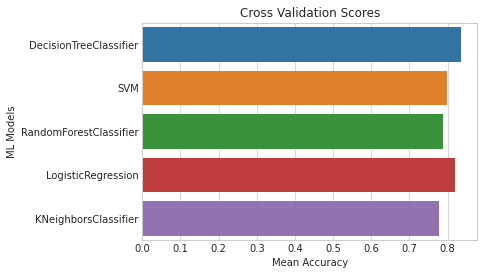

In [97]:
cv_results = pd.DataFrame({"Cross Validation Means" : cv_result, "ML Models" :  ["DecisionTreeClassifier","SVM","RandomForestClassifier","LogisticRegression","KNeighborsClassifier"] })
g = sns.barplot("Cross Validation Means", "ML Models", data = cv_results)
g.set_xlabel("Mean Accuracy")
g.set_title("Cross Validation Scores")

<a id = "33"></a><br>
## Ensemble Modelling

In [98]:
votingC = VotingClassifier(estimators = [("dt", best_estimators[0]),
                                        ("rfc", best_estimators[2]),
                                        ("lr", best_estimators[3])],
                                         voting = "soft", n_jobs = -1)
votingC = votingC.fit(X_train,y_train)
print(accuracy_score(votingC.predict(X_test),y_test))

0.8384879725085911


<a id = "34"></a><br>

## Prediction and Submission

In [99]:
test_PassengerId = test_data["PassengerId"]

In [100]:
test_survived = pd.Series(votingC.predict(test),name = "Survived").astype(int)
results = pd.concat([test_PassengerId, test_survived], axis = 1)
results.to_csv("titanic.csv", index = False)